## Imports
The following libraries are imported for data manipulation, visualization, machine learning, and model evaluation.

In [1]:
# Market Basket Analysis using Apriori Algorithm

## Business Analytics Internship

### Objective
#The objective of this project is to analyze customer purchase transactions and identify products that are frequently bought together using the Apriori Algorithm. The insights obtained can help retailers improve product placement, promotional strategies, cross-selling opportunities, and inventory management.

In [2]:
# Import required libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

# Display plots inside notebook
%matplotlib inline

In [3]:
# Load the dataset into a pandas DataFrame
data = pd.read_csv(r"D:\BA_Internship\Task-1\data\archive\Groceries_dataset.csv")

data.head()

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk


In [4]:
# Dataset Information
print("Dataset Shape:", data.shape)

print("\nColumns:")
print(data.columns)

print("\nFirst 10 Rows:")
display(data.head(10))

print("\nMissing Values:")
print(data.isnull().sum())

Dataset Shape: (38765, 3)

Columns:
Index(['Member_number', 'Date', 'itemDescription'], dtype='str')

First 10 Rows:


,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk
5,4941,14-02-2015,rolls/buns
6,4501,08-05-2015,other vegetables
7,3803,23-12-2015,pot plants
8,2762,20-03-2015,whole milk
9,4119,12-02-2015,tropical fruit



Missing Values:
Member_number      0
Date               0
itemDescription    0
dtype: int64


In [5]:
# Group products by each customer transaction

transactions = data.groupby("Member_number")["itemDescription"].apply(list)

transactions.head()

Member_number
1000    [soda, canned beer, sausage, sausage, whole mi...
1001    [frankfurter, frankfurter, beef, sausage, whol...
1002    [tropical fruit, butter milk, butter, frozen v...
1003    [sausage, root vegetables, rolls/buns, deterge...
1004    [other vegetables, pip fruit, root vegetables,...
Name: itemDescription, dtype: object

In [6]:
# Convert transactions into one-hot encoded format

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)

basket = pd.DataFrame(te_array, columns=te.columns_)

basket.head()

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
1,False,False,False,False,False,False,False,False,True,False,...,False,False,False,True,False,True,False,True,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [7]:
# Generate frequent itemsets using Apriori

frequent_itemsets = apriori(
    basket,
    min_support=0.01,
    use_colnames=True
)

frequent_itemsets.sort_values(by="support", ascending=False).head(10)

,support,itemsets
113,0.458184,frozenset({whole milk})
69,0.376603,frozenset({other vegetables})
84,0.349666,frozenset({rolls/buns})
94,0.313494,frozenset({soda})
114,0.282966,frozenset({yogurt})
106,0.233710,frozenset({tropical fruit})
85,0.230631,frozenset({root vegetables})
7,0.213699,frozenset({bottled water})
89,0.206003,frozenset({sausage})
1050,0.191380,"frozenset({whole milk, other vegetables})"


In [8]:
# Generate association rules from the frequent itemsets
rules = association_rules(
    frequent_itemsets,
    metric="lift",
    min_threshold=1
)

rules.sort_values(by="lift", ascending=False).head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
15182,"frozenset({sausage, whole milk, other vegetabl...","frozenset({rolls/buns, yogurt})",0.050282,0.111339,0.013597,0.270408,2.428689,1.0,0.007998,1.218025,0.619400,0.091854,0.178999,0.196264
15187,"frozenset({rolls/buns, yogurt})","frozenset({sausage, whole milk, other vegetabl...",0.111339,0.050282,0.013597,0.122120,2.428689,1.0,0.007998,1.081831,0.661957,0.091854,0.075641,0.196264
15178,"frozenset({rolls/buns, yogurt, other vegetables})","frozenset({sausage, whole milk})",0.052335,0.106978,0.013597,0.259804,2.428575,1.0,0.007998,1.206467,0.620721,0.093310,0.171133,0.193451
15191,"frozenset({sausage, whole milk})","frozenset({rolls/buns, yogurt, other vegetables})",0.106978,0.052335,0.013597,0.127098,2.428575,1.0,0.007998,1.085650,0.658702,0.093310,0.078893,0.193451
12800,"frozenset({sausage, whole milk})","frozenset({curd, yogurt})",0.106978,0.040277,0.010005,0.093525,2.322046,1.0,0.005696,1.058742,0.637549,0.072897,0.055483,0.170966
12797,"frozenset({curd, yogurt})","frozenset({sausage, whole milk})",0.040277,0.106978,0.010005,0.248408,2.322046,1.0,0.005696,1.188173,0.593239,0.072897,0.158372,0.170966
15183,"frozenset({rolls/buns, sausage, whole milk})","frozenset({yogurt, other vegetables})",0.048743,0.120318,0.013597,0.278947,2.318415,1.0,0.007732,1.219997,0.597810,0.087459,0.180326,0.195977
15186,"frozenset({yogurt, other vegetables})","frozenset({rolls/buns, sausage, whole milk})",0.120318,0.048743,0.013597,0.113006,2.318415,1.0,0.007732,1.072451,0.646451,0.087459,0.067556,0.195977
15175,"frozenset({yogurt, whole milk, other vegetables})","frozenset({rolls/buns, sausage})",0.071832,0.082350,0.013597,0.189286,2.298554,1.0,0.007681,1.131903,0.608665,0.096715,0.116532,0.177197
15194,"frozenset({rolls/buns, sausage})","frozenset({yogurt, whole milk, other vegetables})",0.082350,0.071832,0.013597,0.165109,2.298554,1.0,0.007681,1.111724,0.615642,0.096715,0.100496,0.177197


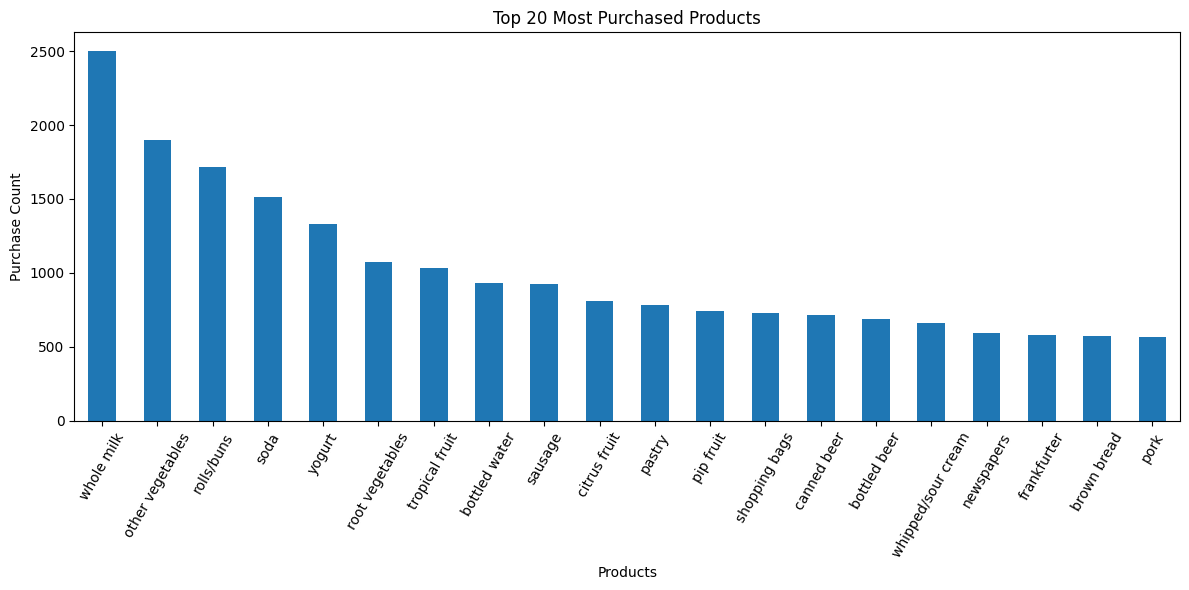

In [9]:
# Visualize the data and analysis results
top_products = data["itemDescription"].value_counts().head(20)

plt.figure(figsize=(12,6))
top_products.plot(kind="bar")
plt.title("Top 20 Most Purchased Products")
plt.xlabel("Products")
plt.ylabel("Purchase Count")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

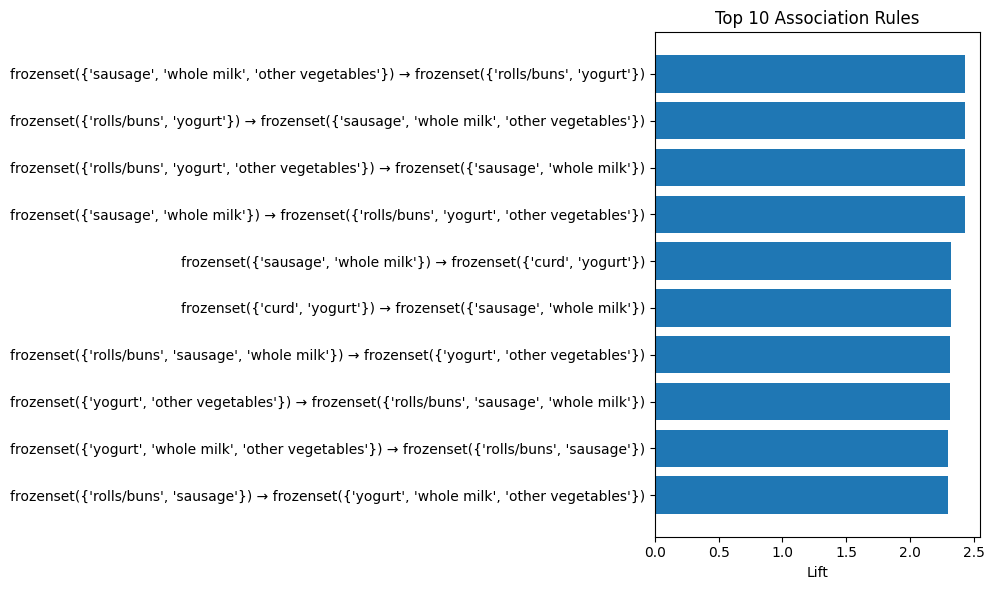

In [10]:
# Visualize the data and analysis results
top_rules = rules.sort_values(by="lift", ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.barh(
    top_rules["antecedents"].astype(str) + " → " + top_rules["consequents"].astype(str),
    top_rules["lift"]
)

plt.xlabel("Lift")
plt.title("Top 10 Association Rules")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Business Insights

- Whole milk appears frequently in customer transactions, indicating it is one of the highest-demand products.
- Certain products are consistently purchased together, creating opportunities for cross-selling.
- High lift values indicate strong relationships between product pairs beyond random chance.
- Retailers can strategically place associated products near each other to encourage additional purchases.
- Promotional bundles can be created for frequently associated products to increase average basket value.

# Recommendations

1. Place frequently purchased product combinations close together on store shelves.
2. Create combo offers for products with high lift values.
3. Optimize inventory planning based on frequent purchase patterns.
4. Recommend related products during checkout in online stores.
5. Use association rules for personalized marketing campaigns.

# Conclusion

This Market Basket Analysis successfully identified frequent purchasing patterns using the Apriori Algorithm. The generated association rules reveal valuable relationships between products that can improve product placement, promotional strategies, and inventory management. These insights support data-driven decision-making for retail businesses and demonstrate the practical application of Business Analytics techniques.

# RetailIQ Module 1 – Product Recommendation Engine

The original internship task identifies products that are frequently purchased together.

As an enhancement, RetailIQ converts these association rules into actionable business recommendations for retail managers. Instead of only displaying analytical metrics, the system recommends product placement, promotional bundles, and cross-selling opportunities.

In [11]:
print("="*70)
print("        RetailIQ - Product Recommendation Engine")
print("="*70)

recommendations = rules.sort_values("lift", ascending=False).head(5)

for index, row in recommendations.iterrows():

    bought = ", ".join(list(row["antecedents"]))
    recommend = ", ".join(list(row["consequents"]))

    print(f"\nCustomer purchases : {bought}")
    print(f"Recommended item   : {recommend}")

    if row["lift"] >= 3:
        print("Priority           : HIGH")
    elif row["lift"] >= 2:
        print("Priority           : MEDIUM")
    else:
        print("Priority           : LOW")

    print("\nBusiness Recommendation")
    print(f"✓ Place '{recommend}' near '{bought}'")
    print("✓ Offer combo discount")
    print("✓ Recommend during checkout")
    print("-"*70)

        RetailIQ - Product Recommendation Engine

Customer purchases : sausage, whole milk, other vegetables
Recommended item   : rolls/buns, yogurt
Priority           : MEDIUM

Business Recommendation
✓ Place 'rolls/buns, yogurt' near 'sausage, whole milk, other vegetables'
✓ Offer combo discount
✓ Recommend during checkout
----------------------------------------------------------------------

Customer purchases : rolls/buns, yogurt
Recommended item   : sausage, whole milk, other vegetables
Priority           : MEDIUM

Business Recommendation
✓ Place 'sausage, whole milk, other vegetables' near 'rolls/buns, yogurt'
✓ Offer combo discount
✓ Recommend during checkout
----------------------------------------------------------------------

Customer purchases : rolls/buns, yogurt, other vegetables
Recommended item   : sausage, whole milk
Priority           : MEDIUM

Business Recommendation
✓ Place 'sausage, whole milk' near 'rolls/buns, yogurt, other vegetables'
✓ Offer combo discount
✓ R

# Business Value Generated

### Problem
Retail stores often know which products sell well but do not know which products should be promoted together.

### RetailIQ Solution
The Product Recommendation Engine transforms association rules into business decisions by recommending:

- Cross-selling opportunities
- Shelf placement optimization
- Promotional product bundles
- Checkout recommendations

### Expected Benefits

- Higher Average Basket Value
- Increased Cross-selling
- Better Customer Experience
- Improved Sales Revenue

# Innovation Added

Unlike a standard Market Basket Analysis, RetailIQ introduces a Product Recommendation Engine that converts analytical results into actionable retail decisions.

This enhancement demonstrates how Business Analytics can directly support managerial decision-making rather than only generating statistical outputs.

# Future Scope

The RetailIQ Product Recommendation Engine can be extended by:

- Integrating real-time transaction data from POS systems.
- Providing personalized product recommendations based on customer purchase history.
- Building an interactive dashboard for retail managers.
- Comparing Apriori with FP-Growth for performance optimization.
- Integrating inventory management to automatically adjust stock levels based on buying patterns.